In [ ]:
esokeyy/TC_Project_New!git clone https://github.com/Hadeer-Mohamed-Eld

Cloning into 'TC_Project_New'...
remote: Enumerating objects: 3904, done.
remote: Total 3904 (delta 0), reused 0 (delta 0), pack-reused 3904 (from 1)
Receiving objects: 100% (3904/3904), 322.44 MiB | 28.22 MiB/s, done.
Resolving deltas: 100% (25/25), done.
Updating files: 100% (3550/3550), done.


In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.0 MB/s eta 0:00:00


In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import models, transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from PIL import Image
import random
import pydicom

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

ModuleNotFoundError: No module named 'pydicom'

# Image Loading and Preprocessing 

In [ ]:
# loading data (augmented and original) for tc and normal into one dataset with labels(tc or normal) but spliting it into train and test
def load_data(tc_aug_path, tc_sim_path, normal_path):
  data = []
  labels = []
  classes = [] # To store 'early', 'late', or 'normal' stage

  # Load TC Augmented images (considered 'late' stage)
  for root, _, files in os.walk(tc_aug_path):
      for tc_file in files:
          if tc_file.lower().endswith(('.png', '.jpg', '.jpeg', '.dcm')): # Added file extension check
              img_path = os.path.join(root, tc_file)
              try:
                  # Attempt to load image, handling DICOM
                  if tc_file.lower().endswith('.dcm'):
                      ds = pydicom.dcmread(img_path)
                      img = ds.pixel_array
                      img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
                      img = img.astype(np.uint8)
                      img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # Convert DICOM (often grayscale) to RGB
                  else:
                      img = cv2.imread(img_path, cv2.IMREAD_COLOR) # Load as color image
                      if img is not None and len(img.shape) == 2: # Check if loaded as grayscale unexpectedly
                           img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)


                  if img is not None: # Check if image was loaded successfully
                      img = cv2.resize(img, (224, 224)) # Resize to 224x224
                      img = img.astype('float32') / 255.0
                      data.append(img)
                      labels.append('tc')
                      classes.append('late') # Augmented TC images are considered 'late' stage
                  else:
                      print(f"Warning: Could not load image {img_path}") # Print warning for failed loads
              except Exception as e:
                  print(f"Error loading image {img_path}: {e}") # Catch other potential errors

  # Load Simulated TC images

  if os.path.exists(tc_sim_path):
      for sim_file in os.listdir(tc_sim_path):
          if sim_file.lower().endswith(('.png', '.jpg', '.jpeg')): # Assuming simulated are png/jpg
              img_path = os.path.join(tc_sim_path, sim_file)
              try:
                  img = cv2.imread(img_path, cv2.IMREAD_COLOR)
                  if img is not None and len(img.shape) == 2:
                      img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

                  if img is not None:
                      img = cv2.resize(img, (224, 224)) # Resize to 224x224
                      img = img.astype('float32') / 255.0
                      data.append(img)
                      labels.append('tc')
                      classes.append('early') # Add the stage ('early') to classes
                  else:
                      print(f"Warning: Could not load simulated image {img_path}")
              except Exception as e:
                  print(f"Error loading simulated image {img_path}: {e}")


  # Load Normal images
  for normal_file in os.listdir(normal_path):
      if normal_file.lower().endswith(('.png', '.jpg', '.jpeg', '.dcm')): # Added file extension check
          img_path = os.path.join(normal_path, normal_file)
          try:
              # Attempt to load image, handling DICOM
              if normal_file.lower().endswith('.dcm'):
                  ds = pydicom.dcmread(img_path)
                  img = ds.pixel_array
                  img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
                  img = img.astype(np.uint8)
                  img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # Convert DICOM (often grayscale) to RGB
              else:
                  img = cv2.imread(img_path, cv2.IMREAD_COLOR) # Load as color image
                  if img is not None and len(img.shape) == 2: # Check if loaded as grayscale unexpectedly
                       img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)


              if img is not None: # Check if image was loaded successfully
                  img = cv2.resize(img, (224, 224)) # Resize to 224x224
                  img = img.astype('float32') / 255.0
                  data.append(img)
                  labels.append('normal')
                  classes.append('normal') # Normal images are 'normal' stage
              else:
                  print(f"Warning: Could not load image {img_path}") # Print warning for failed loads
          except Exception as e:
              print(f"Error loading image {img_path}: {e}") # Catch other potential errors


  data = np.array(data)
  labels = np.array(labels)
  classes = np.array(classes)
  return data, labels, classes

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


tc_augmented = '/content/TC_Project_New/dataset/augmented'
tc_simulated = '/content/TC_Project_New/dataset/lesion_simulated/early'
normal = '/content/TC_Project_New/dataset/raw/normal'
data , labels, classes = load_data(tc_augmented,tc_simulated, normal)

In [ ]:
data.shape

(2962, 224, 224, 3)

In [ ]:
import numpy as np

# Count the occurrences of each unique label
unique_labels, counts = np.unique(labels, return_counts=True)

# Print the counts
for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count} occurrences")

Label normal: 2218 occurrences
Label tc: 744 occurrences


In [ ]:
classes

array(['late', 'late', 'late', ..., 'normal', 'normal', 'normal'],
      dtype='<U6')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)


In [ ]:
le.classes_

array(['normal', 'tc'], dtype='<U6')

In [ ]:
le2 = LabelEncoder()
classes = le2.fit_transform(classes)

In [ ]:
le2.classes_

array(['early', 'late', 'normal'], dtype='<U6')

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=42, stratify=labels,shuffle=True)

In [ ]:
y_train

array([1, 0, 0, ..., 0, 0, 1])

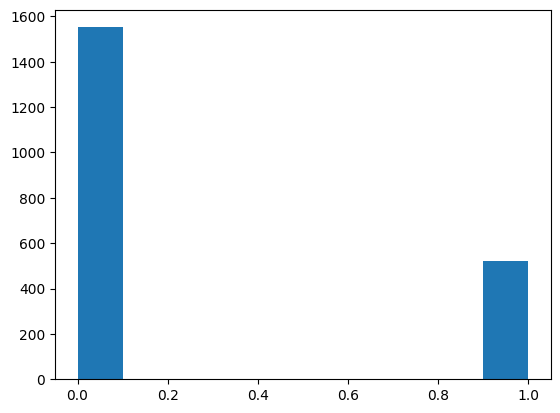

In [ ]:
import matplotlib.pyplot as plt
plt.hist(y_train)
plt.show()

In [ ]:
data.shape

(2962, 224, 224, 3)

In [ ]:
tc_images = []
stages = []
for i in range(len(data)):
  if classes[i] == 1 or classes[i] == 0:
    tc_images.append(data[i])
    stages.append(classes[i])


In [ ]:
len(data)

2962

In [ ]:
from sklearn.model_selection import train_test_split
f_train, f_test, l_train, l_test = train_test_split(tc_images, stages, test_size=0.2, random_state=42, stratify=stages,shuffle=True)

In [ ]:
print(stages)

[np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)

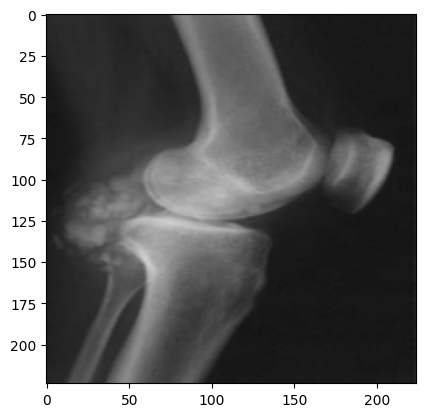

In [ ]:

plt.imshow(f_train[0])

# 2nd Model (late vs. early)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
import tensorflow as tf

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
import tensorflow as tf

model2 = Sequential()
model2.add(ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3)))
model2.add(GlobalAveragePooling2D())
model2.add(Dense(256, activation='relu'))
model2.add(BatchNormalization()) # Added Batch Normalization
model2.add(Dropout(0.6)) # Increased dropout
model2.add(Dense(128, activation='relu')) # Added another dense layer
model2.add(BatchNormalization()) # Added Batch Normalization
model2.add(Dropout(0.6)) # Added another dropout layer
model2.add(Dense(1, activation='sigmoid'))

In [ ]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15)
checkpoint = tf.keras.callbacks.ModelCheckpoint('/content/drive/MyDrive/TC_Project/models/binary_classifier/best_model3.keras', monitor='val_loss', save_best_only=True)

In [ ]:
hist2 = model2.fit(np.array(f_train), np.array(l_train), epochs=50, validation_split=0.2,batch_size=16 ,callbacks=[early_stop,checkpoint])

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.6380 - loss: 0.7702 - val_accuracy: 0.7815 - val_loss: 10.8892
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 669ms/step - accuracy: 0.8085 - loss: 0.4951 - val_accuracy: 0.2185 - val_loss: 8.8367
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 344ms/step - accuracy: 0.9180 - loss: 0.2386 - val_accuracy: 0.7815 - val_loss: 0.8847
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 577ms/step - accuracy: 0.8718 - loss: 0.4058 - val_accuracy: 0.7815 - val_loss: 0.7519
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - accuracy: 0.9160 - loss: 0.2324 - val_accuracy: 0.2185 - val_loss: 0.8023
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.9229 - loss: 0.2699 - val_accuracy: 0.2185 - val_loss: 0.8402
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 567ms/step - accuracy: 0.9554 - loss: 0.1573 - val_accuracy: 0.7815 - val_loss: 0.6538
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.9521 - loss: 0.1770 - val_accurac

In [ ]:
result = model2.evaluate(np.array(f_test), np.array(l_test))
print("Test Loss:", result[0])
print("Test Accuracy:", result[1])

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9407 - loss: 0.3739
Test Loss: 0.38335293531417847
Test Accuracy: 0.9328858852386475


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       117
           1       0.84      0.84      0.84        32

    accuracy                           0.93       149
   macro avg       0.90      0.90      0.90       149
weighted avg       0.93      0.93      0.93       149



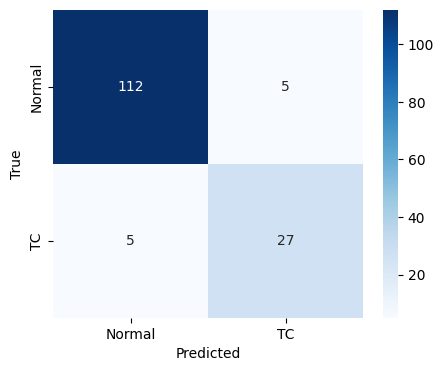

ROC AUC: 0.9025106837606837


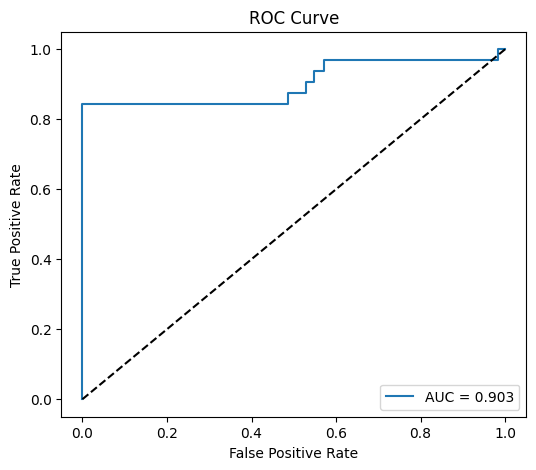

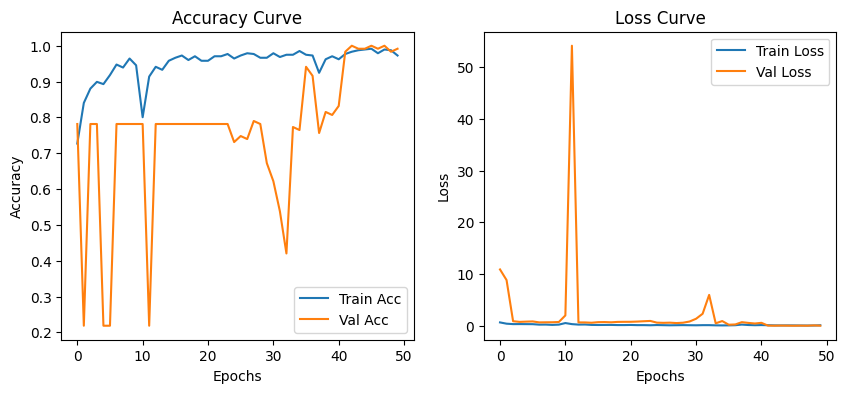

In [ ]:

y_prob = model2.predict(np.array(f_test))
y_pred = (y_prob > 0.5).astype("int32")

# Classification Report
print("Classification Report:\n", classification_report(l_test, y_pred)) 

# Confusion Matrix
cm = confusion_matrix(l_test, y_pred) 
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "TC"], yticklabels=["Normal", "TC"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -----------------------------
# 6. ROC Curve + AUC
# -----------------------------
from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(l_test, y_prob) # Changed y_test to l_test
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(l_test, y_prob) # Changed y_test to l_test
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "k--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# -----------------------------
plt.figure(figsize=(10,4))

# Accuracy curve
plt.subplot(1,2,1)
plt.plot(hist2.history["accuracy"], label="Train Acc")
plt.plot(hist2.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

# Loss curve
plt.subplot(1,2,2)
plt.plot(hist2.history["loss"], label="Train Loss")
plt.plot(hist2.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.show()